In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
deliveries = pd.read_csv('../data/deliveries.csv')
matches    = pd.read_csv('../data/matches.csv')

print("Deliveries shape:", deliveries.shape)
print("Matches shape   :", matches.shape)
print("\nDeliveries columns:\n", deliveries.columns.tolist())
print("\nMatches columns:\n", matches.columns.tolist())

Deliveries shape: (260920, 17)
Matches shape   : (1095, 20)

Deliveries columns:
 ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']

Matches columns:
 ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [ ]:
print("Missing values in deliveries:")
print(deliveries.isnull().sum())

print("\nMissing values in matches:")
print(matches.isnull().sum())

print("\nFirst 3 rows:")
deliveries.head(3)

Missing values in deliveries:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

Missing values in matches:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2       

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [ ]:
# Check the actual column names
print(deliveries.columns.tolist())


['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [ ]:
deliveries.fillna(0, inplace=True)

# Rename batter to batsman
deliveries.rename(columns={'batter': 'batsman'}, inplace=True)

# Runs per batsman per match
batsman_match = (
    deliveries
    .groupby(['match_id', 'batsman'])['batsman_runs']
    .sum()
    .reset_index()
    .rename(columns={'batsman_runs': 'runs_scored'})
)

# Balls faced — exclude wide balls using extras_type
balls = (
    deliveries[deliveries['extras_type'] != 'wides']
    .groupby(['match_id', 'batsman'])['ball']
    .count()
    .reset_index()
    .rename(columns={'ball': 'balls_faced'})
)

batsman_match = batsman_match.merge(balls, on=['match_id', 'batsman'], how='left')
batsman_match['balls_faced'].fillna(1, inplace=True)
batsman_match['strike_rate'] = (batsman_match['runs_scored'] / batsman_match['balls_faced']) * 100

print("✅ Basic features built!")
print(batsman_match.shape)
batsman_match.head()

✅ Basic features built!
(16515, 5)


,match_id,batsman,runs_scored,balls_faced,strike_rate
0,335982,AA Noffke,9,10.0,90.000000
1,335982,B Akhil,0,2.0,0.000000
2,335982,BB McCullum,158,73.0,216.438356
3,335982,CL White,6,10.0,60.000000
4,335982,DJ Hussey,12,12.0,100.000000


In [ ]:
# Check matches columns first
print(matches.columns.tolist())


['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [ ]:
# Merge venue info
match_info = matches[['id', 'venue']].rename(columns={'id': 'match_id'})
batsman_match = batsman_match.merge(match_info, on='match_id', how='left')

# Venue average
venue_avg = (
    batsman_match.groupby('venue')['runs_scored']
    .mean()
    .reset_index()
    .rename(columns={'runs_scored': 'venue_avg'})
)
batsman_match = batsman_match.merge(venue_avg, on='venue', how='left')

print("✅ Venue features added!")
print(batsman_match.shape)
batsman_match.head()

✅ Venue features added!
(16515, 7)


,match_id,batsman,runs_scored,balls_faced,strike_rate,venue,venue_avg
0,335982,AA Noffke,9,10.0,90.000000,M Chinnaswamy Stadium,19.957247
1,335982,B Akhil,0,2.0,0.000000,M Chinnaswamy Stadium,19.957247
2,335982,BB McCullum,158,73.0,216.438356,M Chinnaswamy Stadium,19.957247
3,335982,CL White,6,10.0,60.000000,M Chinnaswamy Stadium,19.957247
4,335982,DJ Hussey,12,12.0,100.000000,M Chinnaswamy Stadium,19.957247


In [ ]:
# Sort for rolling calculations
batsman_match = batsman_match.sort_values(['batsman', 'match_id']).reset_index(drop=True)

# Career average (past data only)
batsman_match['career_avg'] = (
    batsman_match.groupby('batsman')['runs_scored']
    .transform(lambda x: x.expanding().mean().shift(1))
)

# Last 5 matches average
batsman_match['last5_avg'] = (
    batsman_match.groupby('batsman')['runs_scored']
    .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1))
)

print("✅ Rolling features added!")
print(batsman_match.shape)
batsman_match.head()

✅ Rolling features added!
(16515, 9)


,match_id,batsman,runs_scored,balls_faced,strike_rate,venue,venue_avg,career_avg,last5_avg
0,548346,A Ashish Reddy,10,10.0,100.0,Wankhede Stadium,19.746215,NaN,NaN
1,548352,A Ashish Reddy,3,3.0,100.0,"MA Chidambaram Stadium, Chepauk",20.100000,10.00,10.00
2,548359,A Ashish Reddy,8,8.0,100.0,"Rajiv Gandhi International Stadium, Uppal",19.611342,6.50,6.50
3,548373,A Ashish Reddy,10,4.0,250.0,"Rajiv Gandhi International Stadium, Uppal",19.611342,7.00,7.00
4,548376,A Ashish Reddy,4,4.0,100.0,"Rajiv Gandhi International Stadium, Uppal",19.611342,7.75,7.75


In [ ]:
# Keep only active batsmen with enough matches
active = batsman_match.groupby('batsman').size()
batsman_match = batsman_match[batsman_match['batsman'].isin(active[active >= 20].index)]
batsman_match = batsman_match[batsman_match['career_avg'] >= 10]

# Drop nulls
batsman_match.dropna(inplace=True)
batsman_match.reset_index(drop=True, inplace=True)

print("✅ Cleaned dataset shape:", batsman_match.shape)

# Save for Member 2
batsman_match.to_csv('../data/cleaned_data.csv', index=False)
print("✅ Saved to data/cleaned_data.csv — Member 2 can start now!")

✅ Cleaned dataset shape: (12040, 9)
✅ Saved to data/cleaned_data.csv — Member 2 can start now!


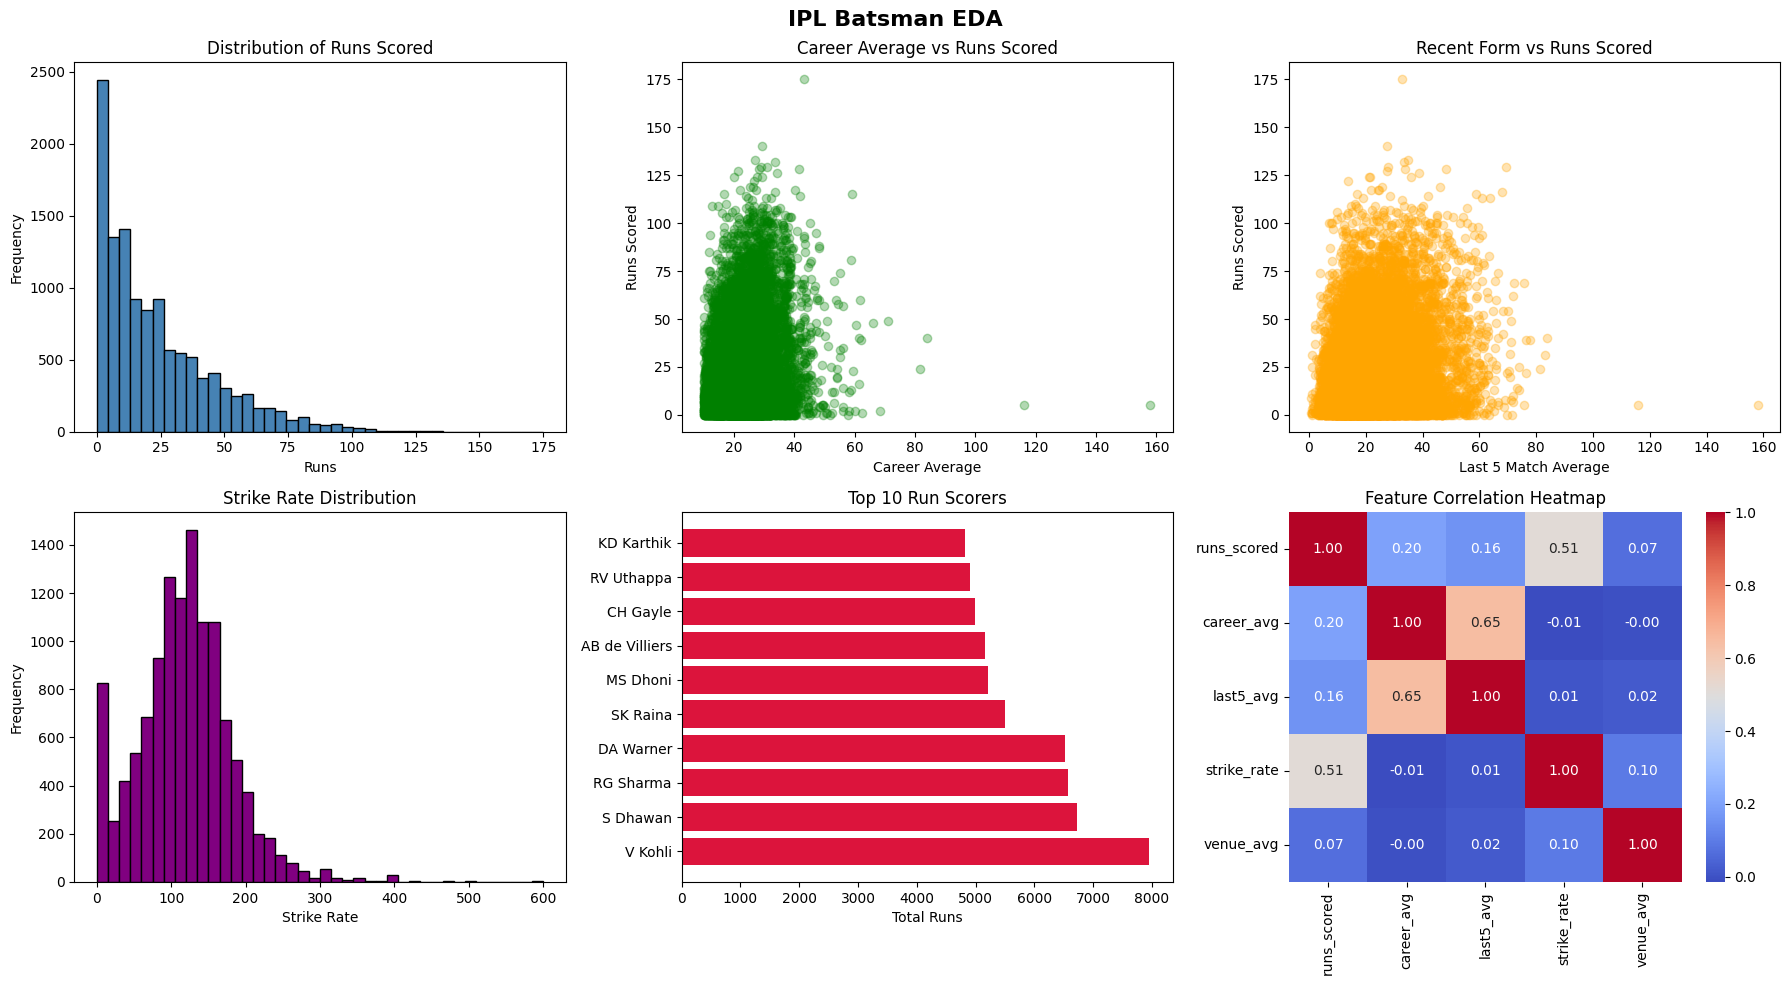

✅ EDA charts saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('IPL Batsman EDA', fontsize=16, fontweight='bold')

# 1. Runs distribution
axes[0,0].hist(batsman_match['runs_scored'], bins=40, color='steelblue', edgecolor='black')
axes[0,0].set_title('Distribution of Runs Scored')
axes[0,0].set_xlabel('Runs')
axes[0,0].set_ylabel('Frequency')

# 2. Career avg vs runs
axes[0,1].scatter(batsman_match['career_avg'], batsman_match['runs_scored'], alpha=0.3, color='green')
axes[0,1].set_title('Career Average vs Runs Scored')
axes[0,1].set_xlabel('Career Average')
axes[0,1].set_ylabel('Runs Scored')

# 3. Recent form vs runs
axes[0,2].scatter(batsman_match['last5_avg'], batsman_match['runs_scored'], alpha=0.3, color='orange')
axes[0,2].set_title('Recent Form vs Runs Scored')
axes[0,2].set_xlabel('Last 5 Match Average')
axes[0,2].set_ylabel('Runs Scored')

# 4. Strike rate distribution
axes[1,0].hist(batsman_match['strike_rate'], bins=40, color='purple', edgecolor='black')
axes[1,0].set_title('Strike Rate Distribution')
axes[1,0].set_xlabel('Strike Rate')
axes[1,0].set_ylabel('Frequency')

# 5. Top 10 run scorers
top10 = (batsman_match.groupby('batsman')['runs_scored']
         .sum().sort_values(ascending=False).head(10))
axes[1,1].barh(top10.index, top10.values, color='crimson')
axes[1,1].set_title('Top 10 Run Scorers')
axes[1,1].set_xlabel('Total Runs')

# 6. Correlation heatmap
cols = ['runs_scored','career_avg','last5_avg','strike_rate','venue_avg']
corr = batsman_match[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('../data/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved!")

In [ ]:
# ============================================
# STAGE 1 — PROBLEM DEFINITION SUMMARY
# ============================================

print("=" * 55)
print("       PROJECT SUMMARY — MEMBER 1 COMPLETE")
print("=" * 55)
print(f"Total records after cleaning : {batsman_match.shape[0]}")
print(f"Total features created       : {batsman_match.shape[1]}")
print(f"Unique batsmen               : {batsman_match['batsman'].nunique()}")
print(f"Features used in model       : career_avg, last5_avg, strike_rate, venue_avg")
print(f"Target variable              : runs_scored")
print(f"Cleaned data saved to        : data/cleaned_data.csv")
print(f"EDA charts saved to          : data/eda_charts.png")
print("\n✅ Member 1 all stages complete!")
print("✅ cleaned_data.csv ready for Member 2!")

       PROJECT SUMMARY — MEMBER 1 COMPLETE
Total records after cleaning : 12040
Total features created       : 9
Unique batsmen               : 193
Features used in model       : career_avg, last5_avg, strike_rate, venue_avg
Target variable              : runs_scored
Cleaned data saved to        : data/cleaned_data.csv
EDA charts saved to          : data/eda_charts.png

✅ Member 1 all stages complete!
✅ cleaned_data.csv ready for Member 2!
